In [1]:
%matplotlib inline
import cv2 
import numpy as np 
import matplotlib.pyplot as plt 
np.set_printoptions(precision=3, suppress=True)

In [ ]:
# World coordinates  XYZ
xyz_list = np.array(
        [[-3, -2, 5],
        [-3, -1, 5],
        [-3, 0, 6],
        [-3, 1, 6],
        [-3, 2, 7],
        [-2, -2, 7],
        [-2, -1, 8],
        [-2, 0, 8],
        [-2, 1, 9],
        [-2, 2, 9],
        [-1, -2, 10],
        [-1, -1, 10],
        [-1, 0, 11],
        [-1, 1, 11],
        [-1, 2, 12],
        [0, -2, 12],
        [0, -1, 13],
        [0, 0, 13],
        [0, 1, 14],
        [0, 2, 14],
        [1, -2, 15],
        [1, -1, 15],
        [1, 0, 16],
        [1, 1, 16],
        [1, 2, 17],
        [2, -2, 17],
        [2, -1, 18],
        [2, 0, 18],
        [2, 1, 19],
        [2, 2, 19],
        ]
        )
# P = k[R|t], fx=fy = 671.13, cx=800, cy=450, central image = (800, 450)
P = np.array([[  671.13,     0.  ,   800.  , -1342.06],      
              [    0.  ,   671.13,   450.  ,     0.  ],
              [    0.  ,     0.  ,     1.  ,     0.  ]])

uv_list = []
for xyz in xyz_list:
    uv = P @ np.append(xyz, 1)
    uv /= uv[2]
    uv_list.append(uv[:2])

uv_list = np.array(uv_list)

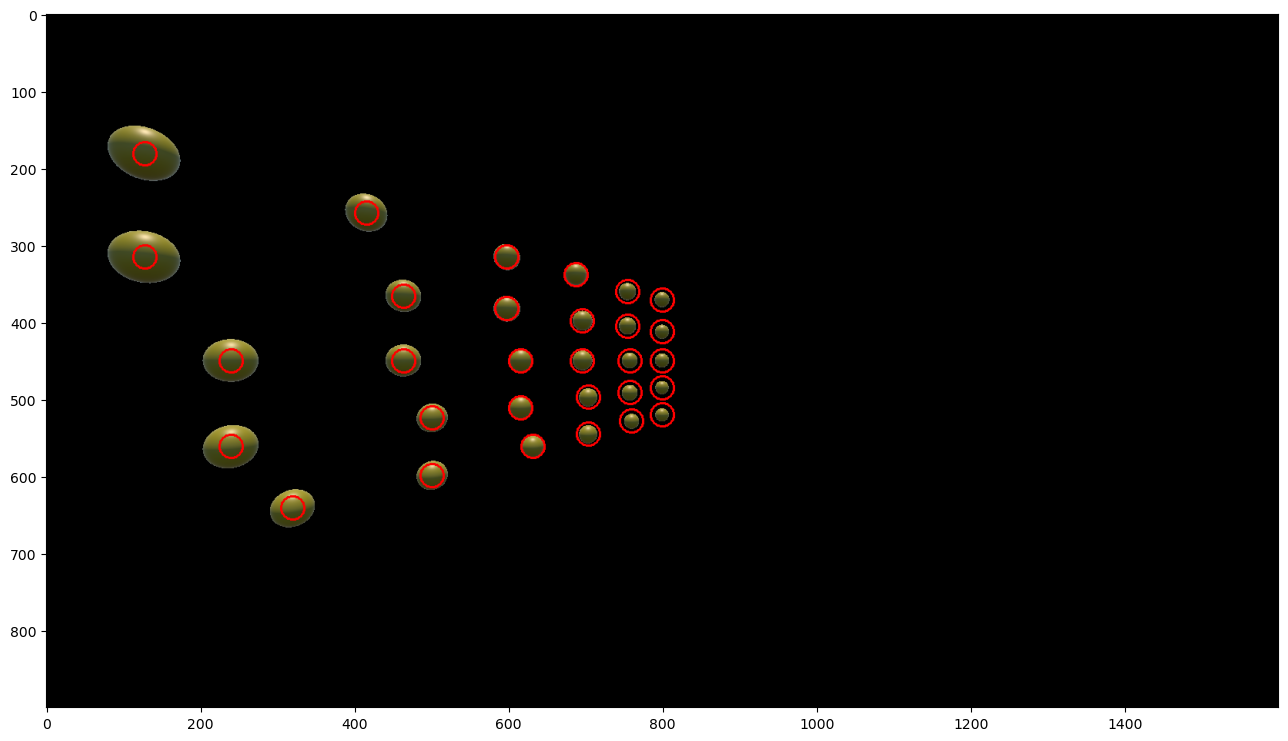

In [4]:
# Load the background image where points will be drawn 
img = cv2.imread("data/sim/wpt_r.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]


# Loop through each projected 2D point and draw a circle

for uv in uv_list:
    # Draw a red circle at the (u, v) location
    cv2.circle(img, (int(uv[0]), int(uv[1])), 15, (255, 0, 0), 2) # (center, radius, color, thickness)

# Display the image with drawn points 
plt.figure(figsize=(16,9))
plt.imshow(img)
plt.show()